# Background — Basic Statistics (อ่านก่อนเข้าโมดูล regression)

โน้ตบุ๊กนี้รวบสถิติพื้นฐานที่โมดูล regression จะใช้ — เจาะจงในมุมงานวัด: ค่าเฉลี่ยและการกระจาย, correlation, normal distribution, และความคิดเรื่อง sampling error ที่ทำให้ "ผลจากกลุ่มตัวอย่าง" ไม่เท่ากับ "ความจริงทั้งประชากร"

## 1. ค่ากลางและการกระจาย — คำศัพท์ที่จะใช้ทุกโมดูล

ddof=1 → สูตร s (กลุ่มตัวอย่าง) ที่รายงานความไม่แน่นอนใช้

In [1]:
import numpy as np

readings = np.array([24.08, 24.11, 24.02, 24.15, 24.09, 24.05, 24.13, 24.07])

mean = readings.mean()
median = np.median(readings)
std = readings.std(ddof=1)

print(f"mean = {mean:.4f}, median = {median:.4f}, std (n-1) = {std:.4f}")


mean = 24.0875, median = 24.0850, std (n-1) = 0.0423


- **mean** = ค่าเฉลี่ย — อ่อนไหวต่อ outlier
- **median** = ค่ากลางตามลำดับ — ทน outlier กว่า
- **std** = ระยะเบี่ยงเบนเฉลี่ยจาก mean — หน่วยเดียวกับข้อมูล; สูตรของกลุ่มตัวอย่างหารด้วย n−1 (ใช้ `ddof=1`)
- **variance** = std² — หน่วยสองชั้น จึงรายงานกันด้วย std มากกว่า

ความอ่อนไหวต่อ outlier: ขยับค่าสุดท้ายจาก 24.07 เป็น 30.0 (เช่น เซนเซอร์พังชั่วขณะ)

In [2]:
bad = readings.copy()
bad[-1] = 30.0
print(f"mean เดิม {mean:.4f} → กับ outlier {bad.mean():.4f} (โดนหนัก)")
print(
    f"median เดิม {median:.4f} → กับ outlier {np.median(bad):.4f}"
    " (แทบไม่ขยับ)"
)


mean เดิม 24.0875 → กับ outlier 24.8287 (โดนหนัก)
median เดิม 24.0850 → กับ outlier 24.1000 (แทบไม่ขยับ)


## 2. Covariance และ correlation — "ตัวแปรสองตัวเดินตามกันแค่ไหน"

- **covariance** วัดทิศทางความสัมพันธ์ (บวก/ลบ) แต่หน่วยเป็น "ผลคูณของสองหน่วย" — อ่านขนาดยาก
- **correlation (r)** = covariance ที่ normalize ให้อยู่ใน [−1, +1] — เทียบข้ามคู่ได้

In [3]:
x = np.array([10.0, 20.0, 30.0, 40.0, 50.0])  # แรงที่กด
y = np.array([0.11, 0.22, 0.32, 0.44, 0.55])  # การอ่านค่าเครื่อง

cov = ((x - x.mean()) * (y - y.mean())).sum() / (len(x) - 1)
r = cov / (x.std(ddof=1) * y.std(ddof=1))
print(f"covariance = {cov:.4g}")
print(f"correlation r = {r:.4f}  (≈ 1 = สัมพันธ์เชิงเส้นเต็มที่)")


covariance = 2.75
correlation r = 0.9997  (≈ 1 = สัมพันธ์เชิงเส้นเต็มที่)


**ข้อควรจำสองข้อ:**
1. r วัดความสัมพันธ์ **เชิงเส้น** เท่านั้น — ข้อมูลโค้งพาราโบลาอาจได้ r ≈ 0 ทั้งที่สัมพันธ์สนิท
2. **correlation ≠ causation** — T กับ RH ในห้องแล็บสัมพันธ์กันเพราะต่างตอบสนองต่อสภาพอากาศเดียวกัน ไม่ใช่เพราะ T ทำให้ RH ขยับ

ตัวอย่างข้อ 1: y = x² มี r ต่ำแต่สัมพันธ์สมบูรณ์

In [4]:
xs = np.linspace(-3, 3, 100)
ys = xs**2
print(
    f"r ของ x กับ x²: {np.corrcoef(xs, ys)[0, 1]:.3f}  ← เกือบศูนย์ "
    f"ทั้งที่เกี่ยวกันแน่นอน"
)


r ของ x กับ x²: 0.000  ← เกือบศูนย์ ทั้งที่เกี่ยวกันแน่นอน


## 3. Normal distribution — รูปทรงที่ noise การวัดชอบอยู่

ข้อผิดพลาดการวัดจากหลายแหล่งเล็ก ๆ ที่ไม่เกี่ยวกัน มักรวมกันเป็นการกระจายปกติ (central limit theorem) กฎนี้ทำให้เรา:
- อธิบาย noise ด้วยสองตัวเลข: mean และ σ
- คาดหวังว่า ~68% อยู่ใน ±1σ, ~95% ใน ±2σ, ~99.7% ใน ±3σ

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

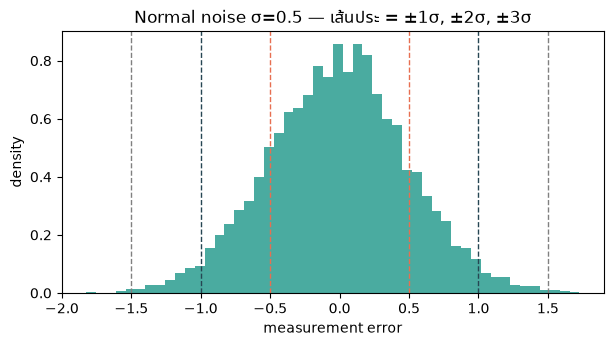

สัดส่วนใน ±1σ = 0.687 (ทฤษฎี 0.683)
สัดส่วนใน ±2σ = 0.953 (ทฤษฎี 0.954)


In [5]:
import matplotlib.pyplot as plt  # noqa: E402

rng = np.random.default_rng(42)
noise = rng.normal(loc=0.0, scale=0.5, size=5000)

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(noise, bins=50, density=True, color="#2a9d8f", alpha=0.85)
for k, c in [(1, "#e76f51"), (2, "#264653"), (3, "gray")]:
    ax.axvline(k * 0.5, color=c, ls="--", lw=1)
    ax.axvline(-k * 0.5, color=c, ls="--", lw=1)
ax.set_xlabel("measurement error")
ax.set_ylabel("density")
ax.set_title("Normal noise σ=0.5 — เส้นประ = ±1σ, ±2σ, ±3σ")
plt.show()

print(f"สัดส่วนใน ±1σ = {np.mean(np.abs(noise) <= 0.5):.3f} (ทฤษฎี 0.683)")
print(f"สัดส่วนใน ±2σ = {np.mean(np.abs(noise) <= 1.0):.3f} (ทฤษฎี 0.954)")


## 4. Sampling error — ค่าเฉลี่ยของกลุ่มตัวอย่างไม่ใช่ค่าจริง

ถ้าวัด 8 ครั้งได้ mean = 24.0875 ค่านี้ไม่ใช่ค่าจริงของปรากฏการณ์ — มันคือค่าประมาณที่มี noise ของตัวเอง **standard error of the mean** บอกขนาดของ noise นั้น:

```text
SEM = s / √n
```

วัดเพิ่ม 4 เท่า → SEM เล็กลงแค่ 2 เท่า — ความแม่นที่ต้องการมากขึ้นมีราคาแพงเป็นรูปรากที่สอง

In [6]:
n = len(readings)
sem = std / np.sqrt(n)
print(f"std = {std:.4f}, n = {n}, SEM = {sem:.4f}")
print(
    f"ช่วงค่าเฉลี่ยที่น่าเชื่อ (±2SEM): "
    f"[{mean - 2 * sem:.4f}, {mean + 2 * sem:.4f}]"
)


std = 0.0423, n = 8, SEM = 0.0150
ช่วงค่าเฉลี่ยที่น่าเชื่อ (±2SEM): [24.0576, 24.1174]


## 5. Percentiles และ IQR — วิธีอธิบายการกระจายที่ทน outlier

**quantile/percentile** = ค่าที่ตัดข้อมูลเป็นสัดส่วน (Q1 = 25%, median = 50%, Q3 = 75%)
**IQR** = Q3 − Q1 — ช่วงกลาง 50% ของข้อมูล — เป็นพื้นฐานของ boxplot และกฎ outlier 1.5×IQR ที่โมดูล EDA ใช้

In [7]:
t = rng.normal(25.0, 1.5, 1000)  # อุณหภูมิห้องแล็บจำลอง
q1, q3 = np.percentile(t, [25, 75])
print(f"Q1 = {q1:.3f}, Q3 = {q3:.3f}, IQR = {q3 - q1:.3f}")
print(
    f"outlier ตามกฎ 1.5×IQR: ต่ำกว่า {q1 - 1.5 * (q3 - q1):.3f} หรือ สูงกว่า {
        q3 + 1.5 * (q3 - q1):.3f}"
)


Q1 = 24.058, Q3 = 26.080, IQR = 2.022
outlier ตามกฎ 1.5×IQR: ต่ำกว่า 21.025 หรือ สูงกว่า 29.113


## 6. ศัพท์ความไม่แน่นอนที่หลักสูตรจะใช้

| ศัพท์ | ความหมายในบริบทนี้ |
|---|---|
| repeatability | ความสอดคล้องเมื่อวัดซ้ำ **เงื่อนไขเดิมทุกอย่าง** (เครื่องเดียว คนเดียว วันเดียว) |
| reproducibility | ความสอดคล้องเมื่อเปลี่ยนเงื่อนไข (เครื่อง/คน/วัน) |
| bias / systematic error | ค่าคลาดที่ไม่เฉลี่ยออกเมื่อวัดซ้ำ — regression แก้ได้ถ้ารู้รูปแบบ |
| random error | ค่าคลาดที่เฉลี่ยออกเมื่อวัดซ้ำ — ลดได้ด้วยการเฉลี่ย (SEM ข้อ 4) |
| u (standard uncertainty) | ประมาณเท่ากับ std ของข้อคลาด |
| U (expanded uncertainty, k=2) | 2 × u — ช่วงครอบคลุม ~95% |

ในภาษา ML: **random error ≈ noise ที่โมเดลอธิบายไม่ได้**, **bias ≈ สิ่งที่ feature/โมเดลที่ดีจะจับได้** การเข้าใจสองฝั่งทำให้คุณคุยกับทั้งนักเมโทรโลยีและนัก ML ได้